In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("AcademicPerformance.csv")
df.head()

,Rollno,Marks,Gender,Age,PhD
0,1,140.0,1,47.0,Yes
1,2,30.0,0,65.0,Yes
2,3,35.1,0,56.0,No
3,4,30.0,1,23.0,No
4,5,80.0,0,NaN,Yes


In [2]:
print("--- Initial Data Info ---")
df.info()
print("\n--- Dimensions of Data ---")
df.shape

--- Initial Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rollno  100 non-null    int64  
 1   Marks   100 non-null    float64
 2   Gender  100 non-null    int64  
 3   Age     84 non-null     float64
 4   PhD     87 non-null     object 
dtypes: float64(2), int64(2), object(1)
memory usage: 4.0+ KB

--- Dimensions of Data ---


(100, 5)

In [3]:
print("\nInitial Statistics:")
df.describe()


Initial Statistics:


,Rollno,Marks,Gender,Age
count,100.000000,100.000000,100.000000,84.000000
mean,50.500000,52.524500,0.500000,47.821429
std,29.011492,42.220933,0.502519,15.037432
min,1.000000,0.250000,0.000000,20.000000
25%,25.750000,20.000000,0.000000,32.750000
50%,50.500000,39.300000,0.500000,50.000000
75%,75.250000,75.500000,1.000000,60.250000
max,100.000000,190.000000,1.000000,77.000000


In [4]:
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


Rollno     0
Marks      0
Gender     0
Age       16
PhD       13
dtype: int64

In [5]:
df['Age'] = df['Age'].fillna(df['Age'].median())
marks_mean = df['Marks'].mean()
df.loc[(df['Marks'] > 100) | (df['Marks'] < 0), 'Marks'] = marks_mean
df['PhD'] = df['PhD'].fillna(df['PhD'].mode()[0])
df.isnull().sum()

Rollno    0
Marks     0
Gender    0
Age       0
PhD       0
dtype: int64

In [18]:
num_cols = df.select_dtypes(include=np.number).columns
print("Numeric columns:", num_cols)

Numeric columns: Index(['Rollno', 'Marks', 'Gender', 'Age'], dtype='object')


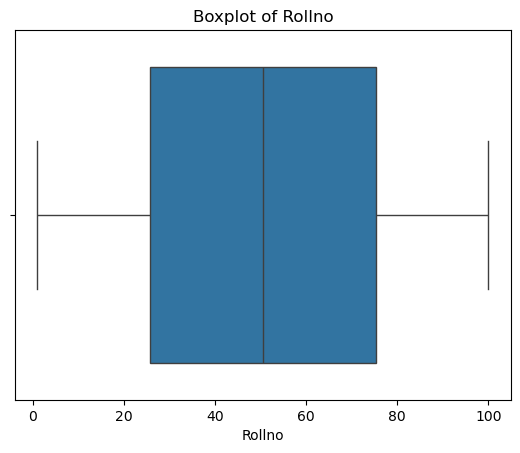

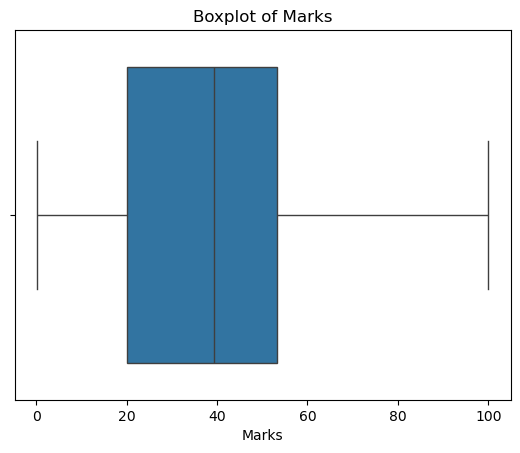

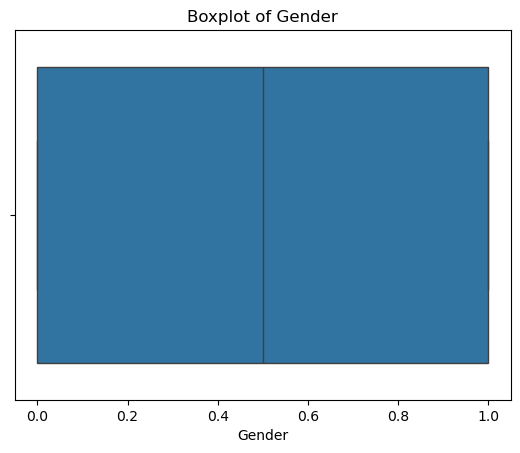

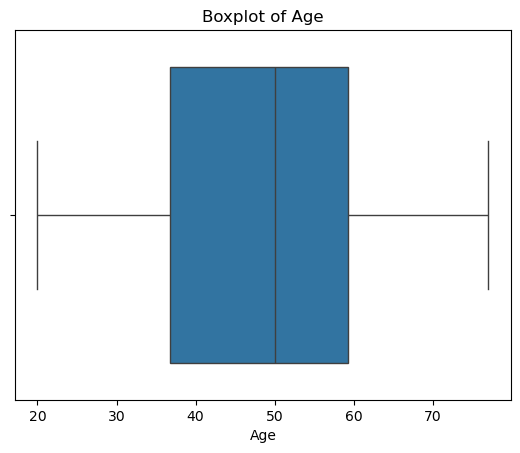

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [6]:
def scan_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers


scan_outliers(df, 'Marks')
scan_outliers(df, 'Age')

,Rollno,Marks,Gender,Age,PhD


In [7]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_cleaned = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df_cleaned


df = remove_outliers(df, 'Marks')
df = remove_outliers(df, 'Age')

print("Outliers removed successfully.")
print(f"Final dataset shape: {df.shape}")

Outliers removed successfully.
Final dataset shape: (100, 5)


In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"After Removal: {col}")
    plt.show()

In [8]:
print("--- Final Cleaned Data ---")
print(df.head(10))

df.to_csv("Cleaned_AcademicPerformance.csv", index=False)

--- Final Cleaned Data ---
   Rollno    Marks  Gender   Age  PhD
0       1  52.5245       1  47.0  Yes
1       2  30.0000       0  65.0  Yes
2       3  35.1000       0  56.0   No
3       4  30.0000       1  23.0   No
4       5  80.0000       0  50.0  Yes
5       6  30.0000       0  27.0   No
6       7  60.0000       1  53.0   No
7       8  31.1000       0  50.0   No
8       9  52.5245       1  44.0  Yes
9      10  51.0000       1  63.0  Yes
